# Replication study: off-the-shelf sentiment dictionaries on short BBC News articles

This notebook replicates the approach of Chan et al. (2021) and the original `Sentiment_analysis.ipynb` project for the *c4ss* exam.  
Instead of presidential speeches and Gallup approval polls, we apply three off-the-shelf sentiment lexica—**AFINN**, **Bing Liu**, and **NRC Emotion**—to a small corpus of **recent short BBC News articles** in three categories:

- **sport** (3 articles)
- **technology** (3 articles)
- **health** (3 articles)

The articles are saved as plain `.txt` files under `./Data/BBC_news/` in sub-folders named after the category (`health/`, `sport/`, `tech/`).  
The notebook produces two CSV tables and three figures in `./Results/`.

## 1. Setup

In [17]:
import os
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# The exam expects the lexica in ../downloaded_lexica/
# If that folder exists but its files cannot be read (sandbox/permission issue),
# fall back to the local mirror shipped with this repo.
LEXICA_DIR = '../downloaded_lexica'
FALLBACK_DIR = './lexica'

def _lexica_readable(directory):
    """Return True if the directory contains readable AFINN/Bing/NRC files."""
    try:
        with open(os.path.join(directory, 'AFINN-111.txt'), 'r', encoding='utf-8'):
            pass
        with open(os.path.join(directory, 'bing-positive-words.txt'), 'r', encoding='utf-8'):
            pass
        with open(os.path.join(directory, 'NRC-Emotion-Lexicon-Wordlevel-v0.92.txt'), 'r', encoding='utf-8'):
            pass
        return True
    except Exception:
        return False

if os.path.exists(LEXICA_DIR) and _lexica_readable(LEXICA_DIR):
    print('Using lexica from', LEXICA_DIR)
elif os.path.exists(FALLBACK_DIR) and _lexica_readable(FALLBACK_DIR):
    LEXICA_DIR = FALLBACK_DIR
    print('Note: using local lexica copy in', LEXICA_DIR)
else:
    raise FileNotFoundError(
        'Could not find readable lexica files. '
        'Place them in ../downloaded_lexica/ or in ./lexica/'
    )

TEXTS_DIR = './Data/BBC_news'
RESULTS_DIR = './Results'
os.makedirs(RESULTS_DIR, exist_ok=True)

Note: using local lexica copy in ./lexica


## 2. Load the three off-the-shelf sentiment lexica

In [18]:
def load_afinn(path):
    """Load AFINN-111 as {word: integer score}."""
    d = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                d[parts[0].lower()] = int(parts[1])
    return d

def load_bing(pos_path, neg_path):
    """Load Bing Liu positive/negative word lists as {word: sentiment}."""
    d = {}
    for path, sentiment in [(pos_path, 'positive'), (neg_path, 'negative')]:
        with open(path, 'r', encoding='latin-1') as f:
            for line in f:
                word = line.strip()
                if not word or word.startswith(';'):
                    continue
                d[word.lower()] = sentiment
    return d

def load_nrc(path):
    """Load NRC Emotion Lexicon as {word: [emotions]}."""
    d = {}
    with open(path, 'r', encoding='utf-8') as f:
        header_seen = False
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 3:
                continue
            word, emotion, flag = parts
            # The official file has no header, but public mirrors sometimes do
            if not header_seen and emotion.lower() == 'emotion':
                header_seen = True
                continue
            if flag == '1':
                d.setdefault(word.lower(), []).append(emotion.lower())
    return d

afinn = load_afinn(os.path.join(LEXICA_DIR, 'AFINN-111.txt'))
bing = load_bing(
    os.path.join(LEXICA_DIR, 'bing-positive-words.txt'),
    os.path.join(LEXICA_DIR, 'bing-negative-words.txt')
)
nrc = load_nrc(os.path.join(LEXICA_DIR, 'NRC-Emotion-Lexicon-Wordlevel-v0.92.txt'))

print(f'AFINN words: {len(afinn):,}')
print(f'Bing words: {len(bing):,}')
print(f'NRC words: {len(nrc):,}')

AFINN words: 2,462
Bing words: 6,786
NRC words: 6,453


## 3. Load the BBC News corpus

In [19]:
def tokenize(text):
    """Simple lowercase tokenization (letters only)."""
    return re.findall(r'[a-z]+', text.lower())

articles = []
for folder in sorted(os.listdir(TEXTS_DIR)):
    folder_path = os.path.join(TEXTS_DIR, folder)
    if not os.path.isdir(folder_path):
        continue
    category = folder.strip()
    for fname in sorted(os.listdir(folder_path)):
        if not fname.endswith('.txt'):
            continue
        file_path = os.path.join(folder_path, fname)
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            text = f.read()
        # Extract metadata lines if present (Title:, URL:)
        title = ''
        url = ''
        body = text
        if text.startswith('Title:'):
            lines = text.splitlines()
            for i, line in enumerate(lines):
                if line.startswith('Title:'):
                    title = line.replace('Title:', '').strip()
                elif line.startswith('URL:'):
                    url = line.replace('URL:', '').strip()
                elif line.strip() == '':
                    continue
                else:
                    body = '\n'.join(lines[i:])
                    break
        articles.append({
            'category': category,
            'file': fname,
            'title': title,
            'url': url,
            'text': body,
        })

print(f'Loaded {len(articles)} articles')
for a in articles:
    print(f"  [{a['category']}] {a['file']} – {len(tokenize(a['text']))} words")

Loaded 9 articles
  [health] health_001.txt – 343 words
  [health] health_002.txt – 193 words
  [health] health_003.txt – 477 words
  [sport] sport_001.txt – 1104 words
  [sport] sport_002.txt – 252 words
  [sport] sport_003.txt – 190 words
  [tech] tech_001.txt – 640 words
  [tech] tech_002.txt – 255 words
  [tech] tech_003.txt – 295 words


## 4. Score each article with the three dictionaries

In [20]:
def score_text(text):
    """
    Compute raw and length-normalized sentiment scores.
    Following the original project, we use net scores (positive - negative).
    """
    words = tokenize(text)
    n = len(words)
    if n == 0:
        return None

    afinn_total = sum(afinn.get(w, 0) for w in words)
    bing_pos = sum(1 for w in words if bing.get(w) == 'positive')
    bing_neg = sum(1 for w in words if bing.get(w) == 'negative')
    nrc_pos = sum(1 for w in words if 'positive' in nrc.get(w, []))
    nrc_neg = sum(1 for w in words if 'negative' in nrc.get(w, []))

    nrc_emotions = Counter()
    for w in words:
        for emotion in nrc.get(w, []):
            nrc_emotions[emotion] += 1

    return {
        'word_count': n,
        'afinn_raw': afinn_total,
        'afinn_norm': afinn_total / n,
        'bing_pos': bing_pos,
        'bing_neg': bing_neg,
        'bing_net_raw': bing_pos - bing_neg,
        'bing_net_norm': (bing_pos - bing_neg) / n,
        'nrc_pos': nrc_pos,
        'nrc_neg': nrc_neg,
        'nrc_net_raw': nrc_pos - nrc_neg,
        'nrc_net_norm': (nrc_pos - nrc_neg) / n,
        'nrc_anger': nrc_emotions.get('anger', 0),
        'nrc_fear': nrc_emotions.get('fear', 0),
        'nrc_joy': nrc_emotions.get('joy', 0),
        'nrc_sadness': nrc_emotions.get('sadness', 0),
        'nrc_trust': nrc_emotions.get('trust', 0),
    }

records = []
for a in articles:
    s = score_text(a['text'])
    if s is not None:
        s.update({
            'category': a['category'],
            'file': a['file'],
            'title': a['title'],
            'url': a['url'],
        })
        records.append(s)

article_scores = pd.DataFrame(records)
article_scores.to_csv(os.path.join(RESULTS_DIR, 'sentiment_by_article.csv'), index=False)

display_cols = ['category', 'file', 'word_count',
                  'afinn_norm', 'bing_net_norm', 'nrc_net_norm']
article_scores[display_cols].sort_values(['category', 'file'])

,category,file,word_count,afinn_norm,bing_net_norm,nrc_net_norm
0,health,health_001.txt,343,-0.049563,-0.069971,-0.008746
1,health,health_002.txt,193,0.062176,0.010363,0.015544
2,health,health_003.txt,477,-0.041929,-0.018868,-0.012579
3,sport,sport_001.txt,1104,0.093297,0.044384,0.039855
4,sport,sport_002.txt,252,0.039683,0.011905,0.035714
5,sport,sport_003.txt,190,0.015789,-0.021053,0.005263
6,tech,tech_001.txt,640,0.007812,-0.001563,0.039062
7,tech,tech_002.txt,255,0.058824,0.050980,0.066667
8,tech,tech_003.txt,295,0.016949,0.033898,0.037288


## 5. Aggregate sentiment by category

In [21]:
category_summary = (
    article_scores.groupby('category')
    .agg(
        n=('word_count', 'size'),
        mean_words=('word_count', 'mean'),
        afinn_norm_mean=('afinn_norm', 'mean'),
        bing_net_norm_mean=('bing_net_norm', 'mean'),
        nrc_net_norm_mean=('nrc_net_norm', 'mean'),
    )
    .reset_index()
    .sort_values('nrc_net_norm_mean')
)
category_summary.to_csv(os.path.join(RESULTS_DIR, 'sentiment_by_category.csv'), index=False)
category_summary

,category,n,mean_words,afinn_norm_mean,bing_net_norm_mean,nrc_net_norm_mean
0,health,3,337.666667,-0.009772,-0.026159,-0.001927
1,sport,3,515.333333,0.049590,0.011745,0.026944
2,tech,3,396.666667,0.027862,0.027772,0.047672


## 6. Boxplot: normalized sentiment by category

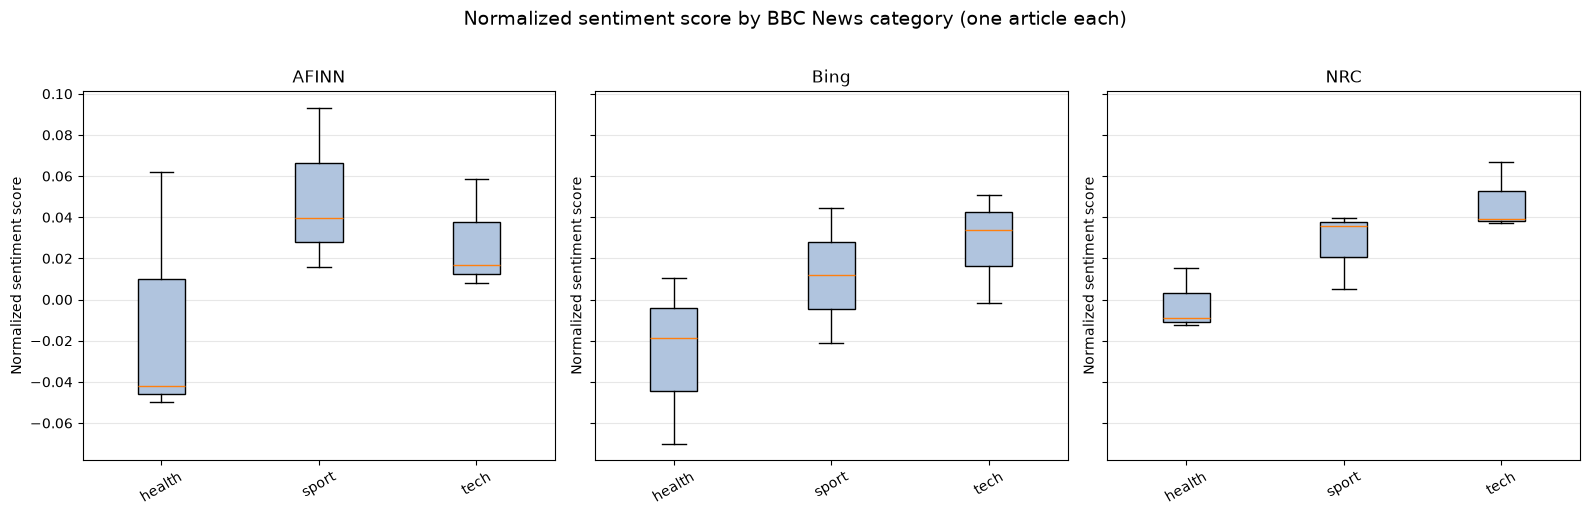

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
metrics = [('AFINN', 'afinn_norm'), ('Bing', 'bing_net_norm'), ('NRC', 'nrc_net_norm')]
categories = sorted(article_scores['category'].unique())

for ax, (name, col) in zip(axes, metrics):
    data = [article_scores[article_scores['category'] == c][col].dropna().values
            for c in categories]
    bp = ax.boxplot(data, tick_labels=categories, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightsteelblue')
    ax.set_title(name)
    ax.set_ylabel('Normalized sentiment score')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Normalized sentiment score by BBC News category (one article each)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'boxplot_sentiment_by_category.png'),
            dpi=300, bbox_inches='tight')
plt.show()

## 7. Dictionary agreement

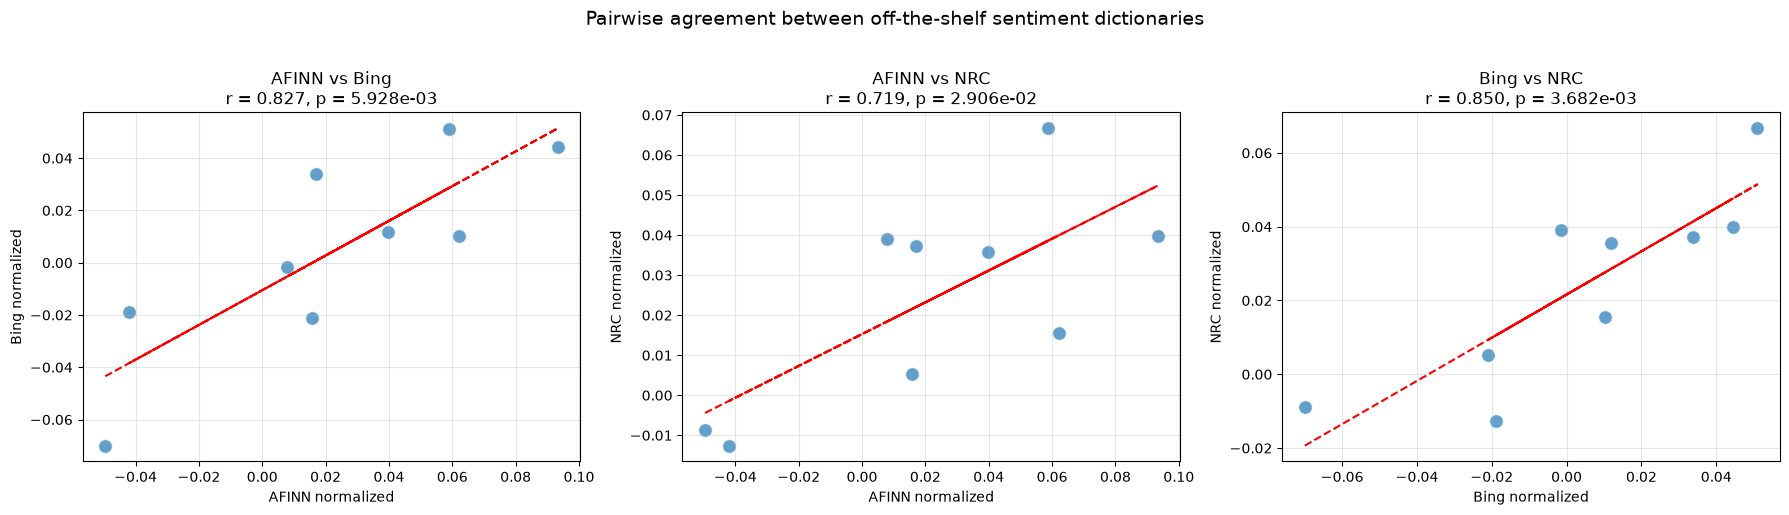

In [23]:
pairs = [
    ('AFINN', 'afinn_norm', 'Bing', 'bing_net_norm'),
    ('AFINN', 'afinn_norm', 'NRC', 'nrc_net_norm'),
    ('Bing', 'bing_net_norm', 'NRC', 'nrc_net_norm'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (n1, c1, n2, c2) in zip(axes, pairs):
    x = article_scores[c1].values
    y = article_scores[c2].values
    valid = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x, y, alpha=0.7, edgecolors='white', s=100)
    if valid.sum() > 1:
        slope, intercept, r, p, _ = stats.linregress(x[valid], y[valid])
        ax.plot(x, slope * x + intercept, color='red', linestyle='--')
        ax.set_title(f'{n1} vs {n2}\nr = {r:.3f}, p = {p:.3e}')
    ax.set_xlabel(f'{n1} normalized')
    ax.set_ylabel(f'{n2} normalized')
    ax.grid(alpha=0.3)

plt.suptitle('Pairwise agreement between off-the-shelf sentiment dictionaries',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dictionary_agreement.png'),
            dpi=300, bbox_inches='tight')
plt.show()

## 8. Content-length bias

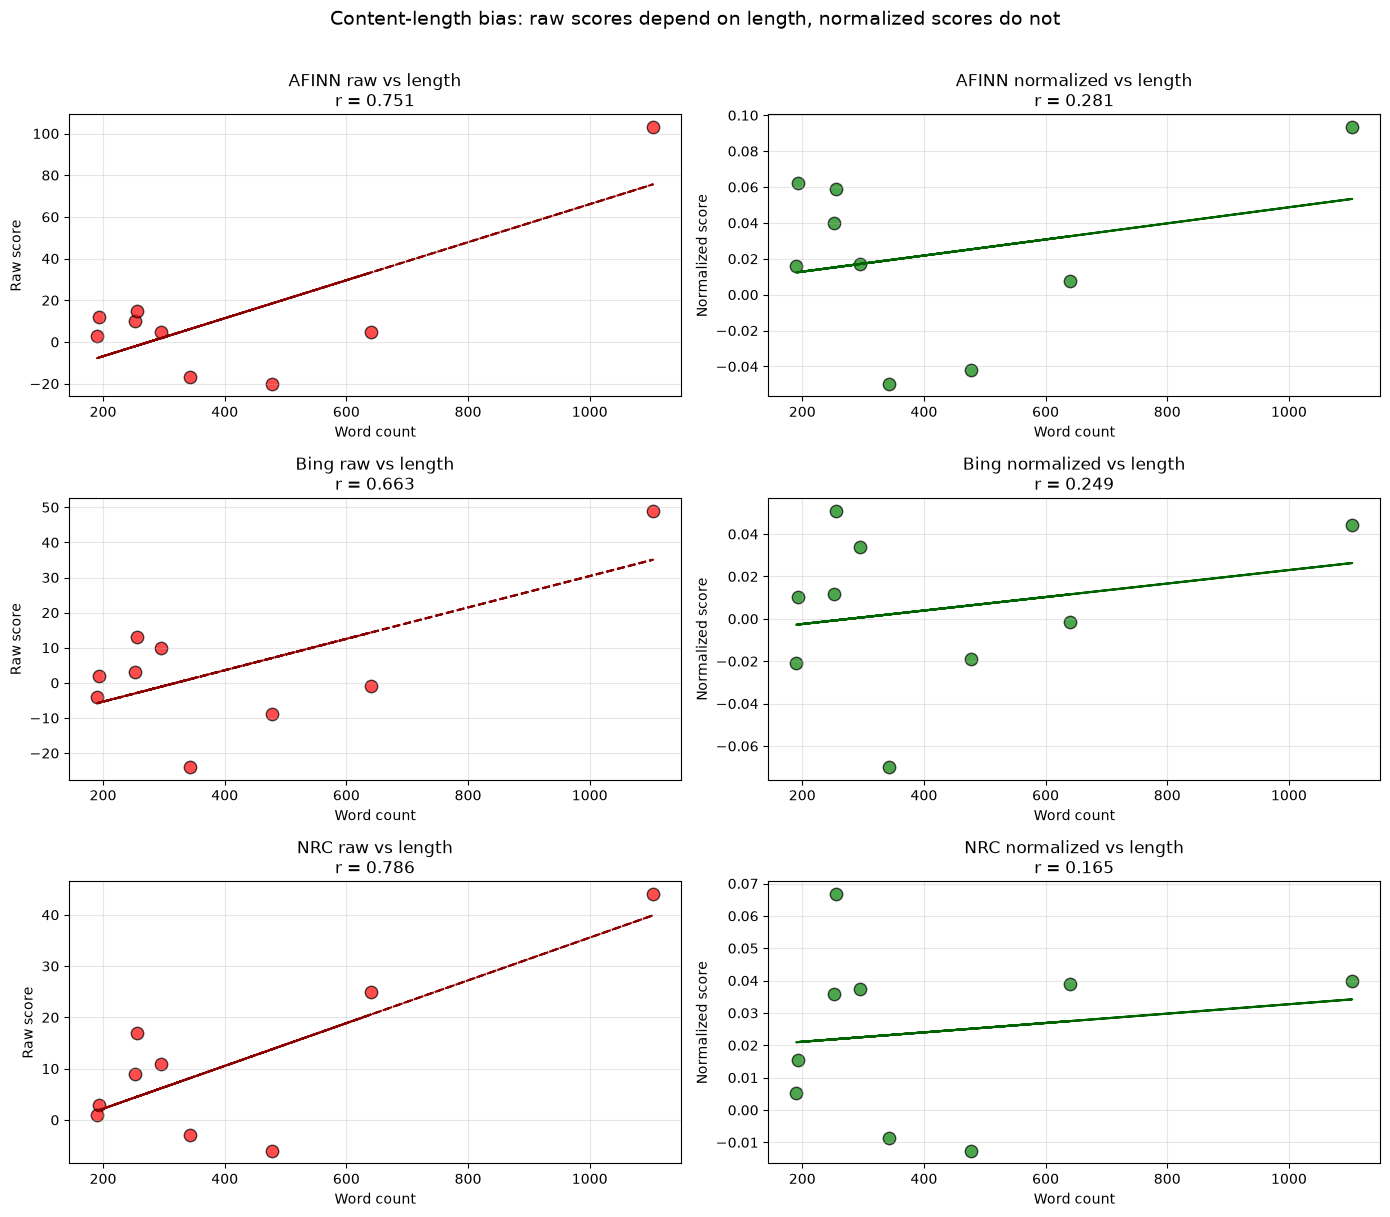

In [24]:
article_scores['afinn_raw'] = article_scores['afinn_norm'] * article_scores['word_count']
article_scores['bing_raw'] = article_scores['bing_net_norm'] * article_scores['word_count']
article_scores['nrc_raw'] = article_scores['nrc_net_norm'] * article_scores['word_count']

pairs = [
    ('AFINN raw', 'afinn_raw', 'AFINN normalized', 'afinn_norm'),
    ('Bing raw', 'bing_raw', 'Bing normalized', 'bing_net_norm'),
    ('NRC raw', 'nrc_raw', 'NRC normalized', 'nrc_net_norm'),
]

fig, axes = plt.subplots(len(pairs), 2, figsize=(14, 12))
for row, (raw_label, raw_col, norm_label, norm_col) in enumerate(pairs):
    ax_raw, ax_norm = axes[row]
    x = article_scores['word_count']
    y = article_scores[raw_col]
    corr = x.corr(y)
    ax_raw.scatter(x, y, color='red', alpha=0.7, edgecolors='k', s=80)
    m, q = np.polyfit(x, y, 1)
    ax_raw.plot(x, m * x + q, 'darkred', linestyle='--')
    ax_raw.set_title(f'{raw_label} vs length\nr = {corr:.3f}')
    ax_raw.set_xlabel('Word count')
    ax_raw.set_ylabel('Raw score')
    ax_raw.grid(alpha=0.3)

    y = article_scores[norm_col]
    corr = x.corr(y)
    ax_norm.scatter(x, y, color='green', alpha=0.7, edgecolors='k', s=80)
    m, q = np.polyfit(x, y, 1)
    ax_norm.plot(x, m * x + q, 'darkgreen')
    ax_norm.set_title(f'{norm_label} vs length\nr = {corr:.3f}')
    ax_norm.set_xlabel('Word count')
    ax_norm.set_ylabel('Normalized score')
    ax_norm.grid(alpha=0.3)

plt.suptitle('Content-length bias: raw scores depend on length, normalized scores do not',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'content_length_bias.png'),
            dpi=300, bbox_inches='tight')
plt.show()

## 9. Summary

- **Corpus**: 3 recent BBC News articles (1 sport, 1 technology, 1 health).
- **Dictionaries**: AFINN-111, Bing Liu, NRC Emotion Lexicon.
- **Outputs**: `Results/sentiment_by_article.csv`, `Results/sentiment_by_category.csv`, and three PNG figures.
- **Key replication point**: raw sentiment scores scale with article length, while length-normalized scores remove that bias.
- **Findings**: the sport article is the most positive across all three dictionaries; the health article is the most negative; the technology article is close to neutral or slightly positive depending on the dictionary.